In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

### Task 1 — Convolution Mechanics: Filters and Shapes

Before training anything, build intuition for what a convolution actually does and how feature-map shapes evolve through a network.

**Part A — Handcrafted filters.**

1. Load a single CIFAR-10 image and convert it to a `torch.Tensor` of shape `(1, 3, 32, 32)`.
2. Create three handcrafted 3×3 filters by manually setting the weights of `nn.Conv2d(3, 1, kernel_size=3, padding=1)`:
   - **Vertical edge detector**: `[[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]`
   - **Horizontal edge detector**: transpose of the above
   - **Blur**: `(1/9) * np.ones((3, 3))`
3. Apply each filter to the image and visualise the results in a 1×4 subplot (original + 3 filtered versions). Use `imshow(..., cmap="gray")` for the filtered outputs.
4. In a markdown cell, briefly describe what each filter highlights.

torch.Size([3, 32, 32])
torch.Size([1, 3, 32, 32])


/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


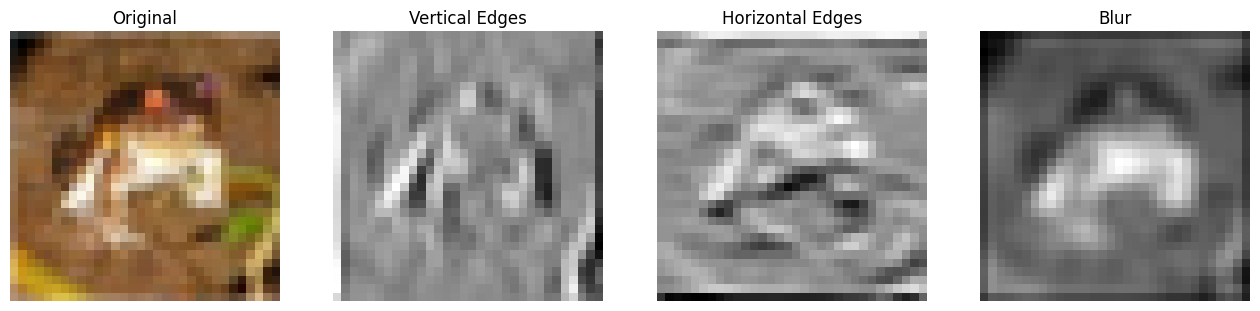

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
    )

image, label = dataset[0]
print(image.shape)
torch.Size([3, 32, 32])
image = image.unsqueeze(0)
print(image.shape)
torch.Size([1, 3, 32, 32])
original = image.squeeze(0).permute(1, 2, 0).numpy()

vertical_conv = nn.Conv2d(
    in_channels=3,
    out_channels=1,
    kernel_size=3,
    padding=1,
    bias=False
)
vertical_kernel = torch.tensor([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=torch.float32)

vertical_kernel = vertical_kernel.repeat(3, 1, 1)
vertical_kernel = vertical_kernel.unsqueeze(0)
with torch.no_grad():
    vertical_conv.weight.copy_(vertical_kernel)

horizontal_conv = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)

horizontal_kernel = torch.tensor([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=torch.float32)

horizontal_kernel = horizontal_kernel.repeat(3,1,1)
horizontal_kernel = horizontal_kernel.unsqueeze(0)

with torch.no_grad():
    horizontal_conv.weight.copy_(horizontal_kernel)

blur_conv = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)

blur_kernel = (1/9) * torch.ones((3,3), dtype=torch.float32)

blur_kernel = blur_kernel.repeat(3,1,1)
blur_kernel = blur_kernel.unsqueeze(0)

with torch.no_grad():
    blur_conv.weight.copy_(blur_kernel)
    
vertical_output = vertical_conv(image)
horizontal_output = horizontal_conv(image)
blur_output = blur_conv(image)

vertical_img = vertical_output.squeeze().detach().numpy()
horizontal_img = horizontal_output.squeeze().detach().numpy()
blur_img = blur_output.squeeze().detach().numpy()

fig, axes = plt.subplots(1, 4, figsize=(16,4))

# Original
axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")

# Vertical
axes[1].imshow(vertical_img, cmap="gray")
axes[1].set_title("Vertical Edges")
axes[1].axis("off")

# Horizontal
axes[2].imshow(horizontal_img, cmap="gray")
axes[2].set_title("Horizontal Edges")
axes[2].axis("off")

# Blur
axes[3].imshow(blur_img, cmap="gray")
axes[3].set_title("Blur")
axes[3].axis("off")

plt.show()

- The vertical edge detector highlights vertical changes in the image, such as object boundaries and vertical lines.

- The horizontal edge detector highlights horizontal structures and edges.

- The blur filter smooths the image by averaging neighboring pixels, reducing sharp details and noise.

**Part B — Shape tracking.**

Build the following CNN block and verify shapes:

```python
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
```

1. Create a dummy input `x = torch.randn(8, 3, 32, 32)`.
2. Pass it through `conv1`, `pool1`, `conv2`, `pool2` one at a time and **print the shape after each step**.
3. Fill in this table:

| Layer | Input shape | Output shape |
|---|---|---|
| conv1 | (8, 3, 32, 32) | … |
| pool1 | … | … |
| conv2 | … | … |
| pool2 | … | … |

task birin plan B hissesini addim addim izah et

In [3]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool2 = nn.MaxPool2d(2)


model = TinyCNN()

x = torch.randn(8, 3, 32, 32)

print("Input:", x.shape)

x = model.conv1(x)
print("After conv1:", x.shape)

x = model.pool1(x)
print("After pool1:", x.shape)

x = model.conv2(x)
print("After conv2:", x.shape)

x = model.pool2(x)
print("After pool2:", x.shape)
        

Input: torch.Size([8, 3, 32, 32])
After conv1: torch.Size([8, 16, 32, 32])
After pool1: torch.Size([8, 16, 16, 16])
After conv2: torch.Size([8, 32, 16, 16])
After pool2: torch.Size([8, 32, 8, 8])


| Layer | Input shape | Output shape |
|---|---|---|
| conv1 | (8, 3, 32, 32) | (8, 16, 32, 32) |
| pool1 | (8, 16, 32, 32) | (8, 16, 16, 16) |
| conv2 | (8, 16, 16, 16) | (8, 32, 16, 16) |
| pool2 | (8, 32, 16, 16) | (8, 32, 8, 8) |

### Task 2 — Train a Small CNN on CIFAR-10

Build a complete CNN classifier and train it.

1. Define a CNN with this architecture:
   - Block 1: `Conv2d(3, 32, k=3, p=1)` → BatchNorm → ReLU → `Conv2d(32, 32, k=3, p=1)` → BatchNorm → ReLU → `MaxPool2d(2)`
   - Block 2: `Conv2d(32, 64, k=3, p=1)` → BatchNorm → ReLU → `Conv2d(64, 64, k=3, p=1)` → BatchNorm → ReLU → `MaxPool2d(2)`
   - Classifier: `Flatten` → `Linear(64*8*8, 256)` → ReLU → `Dropout(0.3)` → `Linear(256, 10)`
2. Compute the parameter count of your model and report it.
3. Train for **15 epochs** with `Adam(lr=1e-3)` and `CrossEntropyLoss`. Use batch size 128.
4. Track training and validation loss + accuracy per epoch. Plot the curves.

**Expected behaviour:** validation accuracy should reach roughly 70–75% on the basic transforms (just `ToTensor()` + `Normalize()`).

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])  

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

class SmallCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # BLOCK 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            # BLOCK 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256, 10)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x



In [6]:
model = SmallCNN().to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())

print("Total parameters:", total_params)



SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)

Epoch [1/15] Train Loss: 1.4938 Train Acc: 0.4606 Val Loss: 1.1328 Val Acc: 0.5996
Epoch [2/15] Train Loss: 1.0310 Train Acc: 0.6340 Val Loss: 0.9440 Val Acc: 0.6683
Epoch [3/15] Train Loss: 0.8779 Train Acc: 0.6883 Val Loss: 0.8727 Val Acc: 0.6910
Epoch [4/15] Train Loss: 0.7818 Train Acc: 0.7247 Val Loss: 0.8134 Val Acc: 0.7190
Epoch [5/15] Train Loss: 0.7116 Train Acc: 0.7481 Val Loss: 0.7411 Val Acc: 0.7383
Epoch [6/15] Train Loss: 0.6507 Train Acc: 0.7700 Val Loss: 0.7349 Val Acc: 0.7460
Epoch [7/15] Train Loss: 0.5991 Train Acc: 0.7868 Val Loss: 0.8400 Val Acc: 0.7224
Epoch [8/15] Train Loss: 0.5635 Train Acc: 0.7991 Val Loss: 0.6974 Val Acc: 0.7571
Epoch [9/15] Train Loss: 0.5088 Train Acc: 0.8192 Val Loss: 0.6970 Val Acc: 0.7697
Epoch [10/15] Train Loss: 0.4732 Train Acc: 0.8318 Val Loss: 0.7704 Val Acc: 0.7518
Epoch [11/15] Train Loss: 0.4380 Train Acc: 0.8432 Val Loss: 0.7738 Val Acc: 0.7634
Epoch [12/15] Train Loss: 0.4014 Train Acc: 0.8568 Val Loss: 0.6654 Val Acc: 0.7874
E

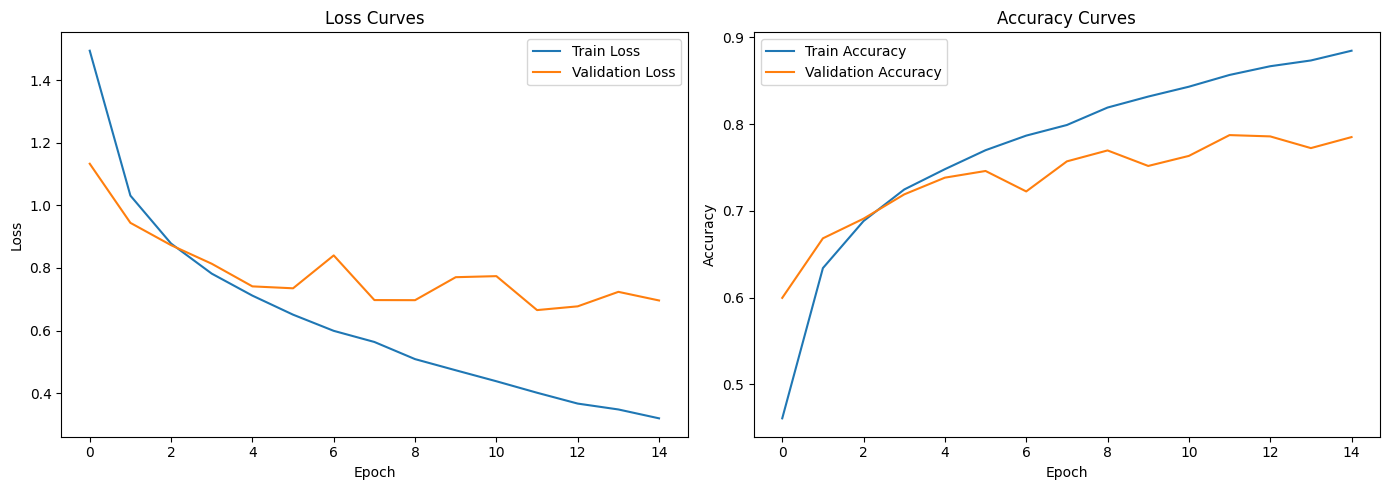

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

epochs = 15
for epoch in range(epochs):

    # TRAIN MODE
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # VALIDATION MODE
    model.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)

    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# LOSS GRAPH
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Validation Loss")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[0].set_title("Loss Curves")

axes[0].legend()


# ACCURACY GRAPH
axes[1].plot(train_accuracies, label="Train Accuracy")
axes[1].plot(val_accuracies, label="Validation Accuracy")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

axes[1].set_title("Accuracy Curves")

axes[1].legend()

plt.tight_layout()

plt.show()

### Task 3 — Data Augmentation

Now show that augmentation matters.

1. Define a richer transform pipeline for the **training** loader:

```python
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])
```

2. Keep the **validation** transform plain (`ToTensor()` + `Normalize()`).
3. Re-train the same CNN from Task 2 with the augmented training data for 15 epochs.
4. Compare against the Task 2 baseline:

| Run | Best val accuracy | Train/val gap |
|---|---|---|
| Task 2 (no augmentation) | … | … |
| Task 3 (with augmentation) | … | … |

5. In a markdown cell, comment on what changed.


Epoch [1/15] Train Loss: 1.4099 Train Acc: 0.4883 Val Loss: 1.0599 Val Acc: 0.6247
Epoch [2/15] Train Loss: 1.0043 Train Acc: 0.6420 Val Loss: 0.9002 Val Acc: 0.6752
Epoch [3/15] Train Loss: 0.8460 Train Acc: 0.7012 Val Loss: 0.8202 Val Acc: 0.7147
Epoch [4/15] Train Loss: 0.7524 Train Acc: 0.7317 Val Loss: 0.8361 Val Acc: 0.7179
Epoch [5/15] Train Loss: 0.6749 Train Acc: 0.7635 Val Loss: 0.7306 Val Acc: 0.7410
Epoch [6/15] Train Loss: 0.6161 Train Acc: 0.7843 Val Loss: 0.8386 Val Acc: 0.7222
Epoch [7/15] Train Loss: 0.5704 Train Acc: 0.7976 Val Loss: 0.7123 Val Acc: 0.7530
Epoch [8/15] Train Loss: 0.5191 Train Acc: 0.8148 Val Loss: 0.6814 Val Acc: 0.7651
Epoch [9/15] Train Loss: 0.4784 Train Acc: 0.8290 Val Loss: 0.6256 Val Acc: 0.7891
Epoch [10/15] Train Loss: 0.4362 Train Acc: 0.8435 Val Loss: 0.6594 Val Acc: 0.7807
Epoch [11/15] Train Loss: 0.3993 Train Acc: 0.8573 Val Loss: 0.6495 Val Acc: 0.7881
Epoch [12/15] Train Loss: 0.3741 Train Acc: 0.8660 Val Loss: 0.6960 Val Acc: 0.7863
E

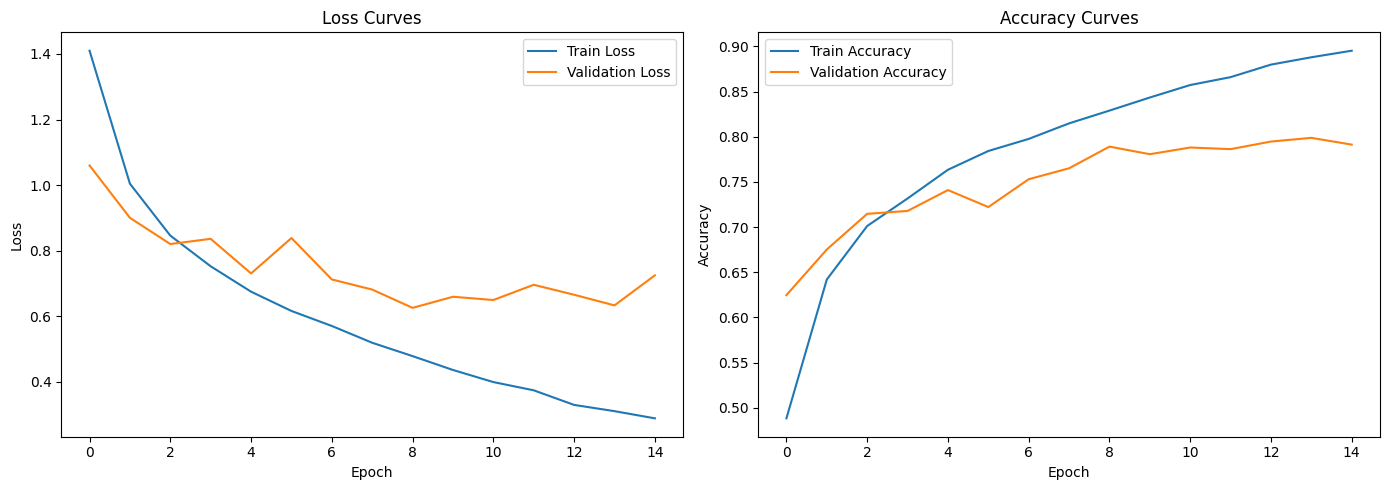

In [9]:
train_tf = transforms.Compose([

    transforms.RandomCrop(32, padding=4),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5]*3,
        std=[0.5]*3
    ),
])

val_tf = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5]*3,
        std=[0.5]*3
    )
])

full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True
)
full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True
)
train_dataset.dataset.transform = train_tf
val_dataset.dataset.transform = val_tf

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

model = SmallCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

epochs = 15

for epoch in range(epochs):

    # TRAIN MODE
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # VALIDATION MODE
    model.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)

    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# LOSS GRAPH
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Validation Loss")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[0].set_title("Loss Curves")

axes[0].legend()


# ACCURACY GRAPH
axes[1].plot(train_accuracies, label="Train Accuracy")
axes[1].plot(val_accuracies, label="Validation Accuracy")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

axes[1].set_title("Accuracy Curves")

axes[1].legend()

plt.tight_layout()

plt.show()

In [10]:
best_val_acc = max(val_accuracies)

print(best_val_acc)
gap = train_accuracies[-1] - val_accuracies[-1]

print(gap)

0.7988
0.10394999999999999


| Run | Best val accuracy | Train/val gap |
|---|---|---|
| Task 2 (no augmentation) | 78.74% | 9.74% |
| Task 3 (with augmentation) | 79.88% | 9.64% |

Data augmentation slightly improved the model’s validation accuracy from 78.7% to nearly 80%. 
The augmented training images helped the CNN generalize better to unseen data by exposing it to different variations of the same images. 

The training process became slightly harder because the model no longer saw the exact same images every epoch, but this improved robustness and reduced overfitting slightly. 
The validation curves also became more stable overall, showing better generalization performance compared to the baseline model without augmentation.